#クロスバリデーション(MFCC, Loudness無)＋最大値

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import os
#from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import mode
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# ファイルとdeliriumの結合
folder_path = Path('./voice_csv_200ms')
all_files = list(folder_path.glob('*.csv'))

df = pd.DataFrame({'filepath': all_files})
#print(df)
files_df = df 

files_df['filename'] = df['filepath'].apply(lambda p: Path(p).name)

files_df['ID'] = files_df['filename'].str.extract(r'ID(\d+)_')
files_df['ID'] = files_df['ID'].astype(int)
#print(files_df.head())

labels_df = pd.read_csv('./delirium.csv')
#print(labels_df)

file_with_labels_df = pd.merge(files_df, labels_df, on='ID', how='left')

file_with_labels_df.drop(columns=['ID', 'Sex'], inplace=True)
print(file_with_labels_df)
#print(file_with_labels_df.columns)

#KFold Cross Validation
model = RandomForestClassifier(random_state=42)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

#CSVファイルのデータ
X_files = file_with_labels_df
#print(X_files)
#せん妄の有無(0 or 1)
y_labels = file_with_labels_df['Delirium']
#print(y_labels[2])

for fold, (train_indices, test_indices) in enumerate(kf.split(X_files, y_labels)):

    train_files = X_files.iloc[train_indices]
    test_files = X_files.iloc[test_indices]

    print(f"--- Fold {fold+1} ---")
    print(f"訓練ファイル数: {len(train_files)}, テストファイル数: {len(test_files)}")

    #print(test_files)

    train_files_path = [folder_path / fname for fname in train_files['filename']]
    test_files_path = [folder_path / fname for fname in test_files['filename']]
    #print(train_files_path)
    train_df = pd.DataFrame()
    test_df = pd.DataFrame()
    for f in train_files_path:
        #df_train_file = pd.read_csv(f).iloc[::2]
        df_train_file = pd.read_csv(f)

        #print(f)
        current_filename = os.path.basename(f)
        #print(current_filename)
        rows = train_files[train_files['filename'] == current_filename]
        #print(rows)
        file_delirium = rows['Delirium'].iloc[0]
        #print(file_delirium)
        df_train_file['Delirium'] = file_delirium
        df_train_file['filename'] = current_filename
        #print(df_train_file)

        #df_train_file['Delirium'] = train_files[train_files['filename'] == current_filename]['Delirium'].iloc[2]
        
        #delete space
        df_train_file['label'] = df_train_file['label'].str.strip()
        #only answer1-10
        max_df1_file = df_train_file[df_train_file["label"].str.match('^answer(10|[1-9])$', na=False)]
        #max_df1_file.info()

        max_df_train_file = max_df1_file.groupby('label').max()
        max_df_train_file = max_df_train_file.reset_index()

        train_df = pd.concat([train_df, max_df_train_file], ignore_index=True)
    #train_df.to_csv('output.csv', index=False, encoding='utf-8-sig')
    test_file_lengths = []
    for f in test_files_path:
        #df_test_file = pd.read_csv(f).iloc[::2]
        df_test_file = pd.read_csv(f)

        #print(f)
        current_filename = os.path.basename(f)
        #print(current_filename)
        rows = test_files[test_files['filename'] == current_filename]
        #print(rows)
        file_delirium = rows['Delirium'].iloc[0]
        #print(file_delirium)
        df_test_file['Delirium'] = file_delirium
        df_test_file['filename'] = current_filename

        #delete space
        df_test_file['label'] = df_test_file['label'].str.strip()
        #only answer1-10
        max_df2_file = df_test_file[df_test_file["label"].str.match('^answer(10|[1-9])$', na=False)]

        max_df_test_file = max_df2_file.groupby('label').max()
        max_df_test_file = max_df_test_file.reset_index()

        test_file_lengths.append(len(max_df_test_file))

        test_df = pd.concat([test_df, max_df_test_file], ignore_index=True)
    #test_df.to_csv('output.csv', index=False, encoding='utf-8-sig')
    #print(train_df)
    #print(test_df)


    #train_df = pd.concat([pd.read_csv(f).iloc[::2] for f in train_files_path], ignore_index=True)
    #test_df = pd.concat([pd.read_csv(f).iloc[::2] for f in test_files_path], ignore_index=True)

    #train_df = pd.concat([pd.read_csv(f) for f in train_files_path], ignore_index=True)
    #test_df = pd.concat([pd.read_csv(f) for f in test_files_path], ignore_index=True)
    #print(train_df)
    #print(test_df)

    print(f"訓練データ行数: {len(train_df)}")
    #train_df = train_df.iloc[::2]
    #train_df = train_df.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(train_df)}")

    #print(f"元の訓練データ行数: {len(test_df)}")
    #test_df = test_df.iloc[::2]
    #test_df = test_df.reset_index(drop=True)
    print(f"テストデータ行数: {len(test_df)}")


    columns_drop = ['start', 'end', 'label', 'alphaRatio_sma3', 'hammarbergIndex_sma3', 'slope0-500_sma3', 'slope500-1500_sma3', 'mfcc1_sma3', 'mfcc2_sma3', 'mfcc3_sma3', 'mfcc4_sma3', 'logRelF0-H1-H2_sma3nz', 'logRelF0-H1-A3_sma3nz','Loudness_sma3', 'original_start', 'original_end', 'Delirium', 'filename']
    #,'Loudness_sma3'

    #print(train_indices)
    #print(test_indices)

    #y_train = y_labels.iloc[train_indices].repeat([len(pd.read_csv(f)) for f in train_files_path])
    #y_test = y_labels.iloc[test_indices].repeat([len(pd.read_csv(f)) for f in test_files_path])
    #print(y_train)

    #print(f"訓練データの正解ラベル数: {len(y_train)}")
    #y_train = y_train.iloc[::2]
    #y_train = y_train.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(y_train)}")

    #print(f"テストデータの正解ラベル数: {len(y_test)}")
    #y_test = y_test.iloc[::2]
    #y_test = y_test.reset_index(drop=True)
    #print(f"間引き後のテストデータ行数: {len(y_test)}")

    y_train = train_df['Delirium']
    #print(y_train)
    y_test = test_df['Delirium']
    #print(y_test)
    X_train = train_df.drop(columns=columns_drop, errors='ignore')
    X_test = test_df.drop(columns=columns_drop, errors='ignore')
    print(f"訓練データの正解ラベル数: {len(y_train)}")
    print(f"テストデータの正解ラベル数: {len(y_test)}")

    #print(X_train)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    #print(y_pred)

    file_predictions = []

    # 各テストファイルの行数を事前に計算しておく

    #test_file_lengths = [len(pd.read_csv(f).iloc[::2]) for f in test_files_path]
    print(test_file_lengths)

    start_idx = 0
    for length in test_file_lengths:
        end_idx = start_idx + length
        #print(start_idx, end_idx)
        predictions_for_this_file = y_pred[start_idx:end_idx]
        #print(predictions_for_this_file.shape)
        majority_vote = mode(predictions_for_this_file)[0]
        #print(majority_vote)
        file_predictions.append(majority_vote)
        start_idx = end_idx

    y_test_files = test_files['Delirium'].values

    test_files_copy = test_files
    #test_files_copy['Predict'] = file_predictions
    test_files_copy = test_files_copy.assign(Prediction=file_predictions)

    print(test_files_copy)

    correct_files = np.sum(np.array(file_predictions) == y_test_files)
    total_files = len(test_files)
    accuracy = correct_files/ total_files

    scores.append(accuracy)
    print("\n")
    print(f"このFoldの正解率 (ファイル単位): {accuracy:.4f} ({correct_files}/{total_files} ファイル正解)\n")

    # 4-2. 混同行列の計算
    # y_test_files (正解ラベル) と file_predictions (予測ラベル) を渡す
    cm = confusion_matrix(y_test_files, file_predictions)

    # 4-3. 見やすいようにDataFrameに変換して表示
    # ラベルが0と1の場合
    cm_df = pd.DataFrame(cm, 
                     index=['正解: 0', '正解: 1'], 
                     columns=['予測: 0', '予測: 1'])

    print("混同行列:")
    print(cm_df)
    print("\n") # 見やすいように改行

    #特徴量の重要度を取得
    feature_names = X_train.columns.tolist()
    
    importances = model.feature_importances_

    #特徴量の名前と重要度をまとめたDataFrameを作成
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    #重要度が高い順にソート
    sorted_importance_df = importance_df.sort_values(by='Importance', ascending=False)

    print(sorted_importance_df)

    #特徴量ごとの散布図を比較
    #feature_name = 'Loudness_sma3'

    #fig, (sp1, sp2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    #fig.suptitle(f'{feature_name}', fontsize=16)

    #sp1.scatter(range(len(X_train)), X_train[feature_name], alpha=0.6)
    #sp1.set_title('train data')
    #sp1.set_xlabel('index')
    #sp1.set_ylabel(feature_name)
    #sp1.grid(True)

    #sp2.scatter(range(len(X_test)), X_test[feature_name], alpha=0.6)
    #sp2.set_title('test data')
    #sp2.set_xlabel('index')
    #sp2.set_ylabel(feature_name)
    #sp2.grid(True)

    #グラフを表示
    #plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    #plt.show()

    

total_accuracy = sum(scores) / len(scores)
print(f"5つのFoldのファイル単位での平均正解率：{total_accuracy:.4f}\n")
print(f"5つのFoldのファイル単位での性能のばらつき(標準偏差)：{np.std(scores):.4f}")

                          filepath        filename  Delirium
0   voice_csv_200ms\ID36_200ms.csv  ID36_200ms.csv         0
1   voice_csv_200ms\ID37_200ms.csv  ID37_200ms.csv         0
2   voice_csv_200ms\ID38_200ms.csv  ID38_200ms.csv         0
3   voice_csv_200ms\ID39_200ms.csv  ID39_200ms.csv         0
4   voice_csv_200ms\ID40_200ms.csv  ID40_200ms.csv         0
5   voice_csv_200ms\ID41_200ms.csv  ID41_200ms.csv         0
6   voice_csv_200ms\ID42_200ms.csv  ID42_200ms.csv         0
7   voice_csv_200ms\ID43_200ms.csv  ID43_200ms.csv         1
8   voice_csv_200ms\ID44_200ms.csv  ID44_200ms.csv         1
9   voice_csv_200ms\ID45_200ms.csv  ID45_200ms.csv         0
10  voice_csv_200ms\ID46_200ms.csv  ID46_200ms.csv         1
11  voice_csv_200ms\ID47_200ms.csv  ID47_200ms.csv         0
12  voice_csv_200ms\ID48_200ms.csv  ID48_200ms.csv         1
13  voice_csv_200ms\ID49_200ms.csv  ID49_200ms.csv         0
14  voice_csv_200ms\ID50_200ms.csv  ID50_200ms.csv         0
15  voice_csv_200ms\ID51

平均

--- Fold 1 ---
訓練ファイル数: 47, テストファイル数: 12


C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\1452900565.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')
C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\1452900565.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')
C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\1452900565.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

訓練データ行数: 425
テストデータ行数: 110
訓練データの正解ラベル数: 425
テストデータの正解ラベル数: 110
0
                          filepath        filename  Delirium  Prediction
0   voice_csv_200ms\ID36_200ms.csv  ID36_200ms.csv         0         0.0
3   voice_csv_200ms\ID39_200ms.csv  ID39_200ms.csv         0         0.0
5   voice_csv_200ms\ID41_200ms.csv  ID41_200ms.csv         0         0.0
12  voice_csv_200ms\ID48_200ms.csv  ID48_200ms.csv         1         0.0
13  voice_csv_200ms\ID49_200ms.csv  ID49_200ms.csv         0         0.0
25  voice_csv_200ms\ID61_200ms.csv  ID61_200ms.csv         0         0.0
34  voice_csv_200ms\ID70_200ms.csv  ID70_200ms.csv         1         1.0
45  voice_csv_200ms\ID81_200ms.csv  ID81_200ms.csv         1         1.0
47  voice_csv_200ms\ID83_200ms.csv  ID83_200ms.csv         1         1.0
49  voice_csv_200ms\ID85_200ms.csv  ID85_200ms.csv         1         0.0
53  voice_csv_200ms\ID89_200ms.csv  ID89_200ms.csv         0         1.0
57  voice_csv_200ms\ID93_200ms.csv  ID93_200ms.csv        

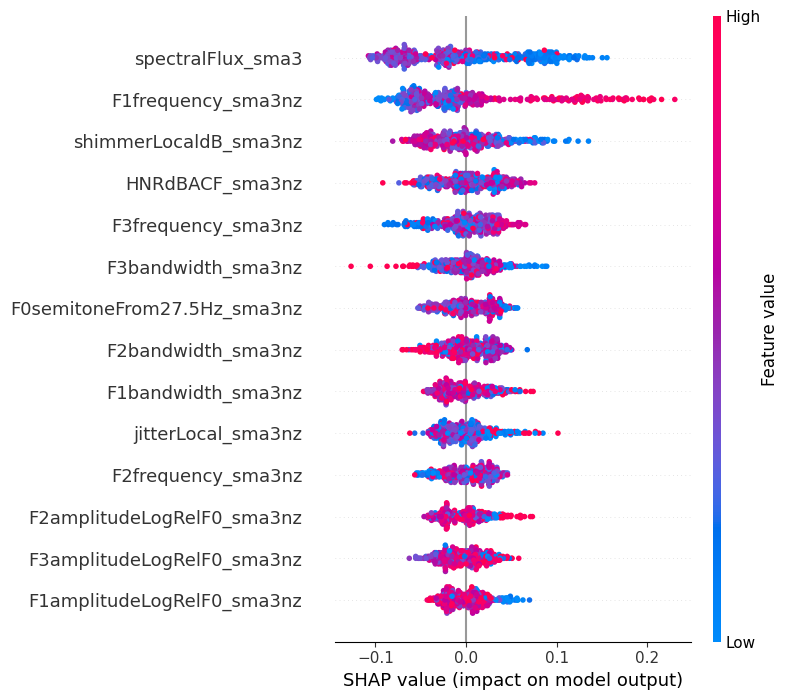

間違えたファイルの (start, end) リスト: [(30, 40), (83, 92)]
SHAP Values (error) の形状: (19, 14, 2)


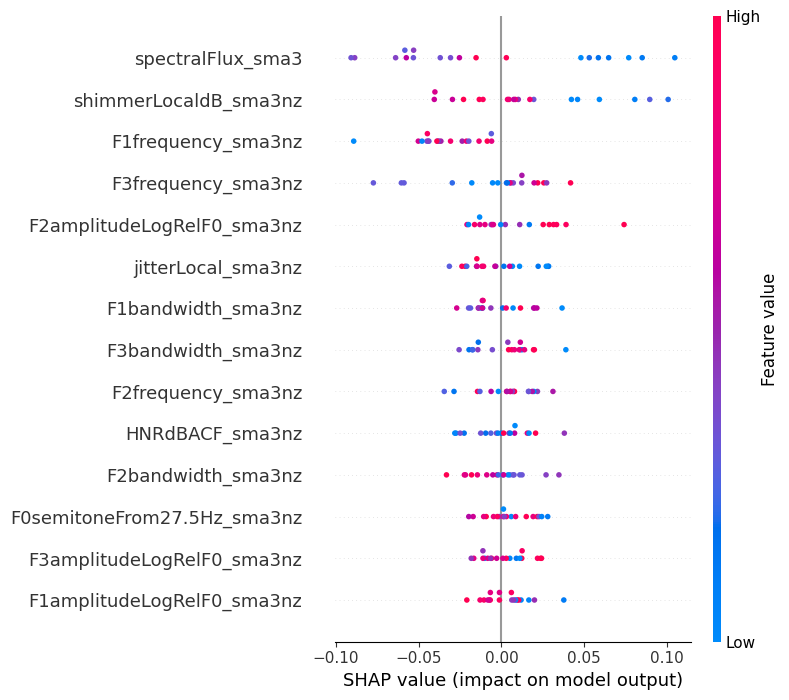

--- Fold 2 ---
訓練ファイル数: 47, テストファイル数: 12


C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\1452900565.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')
C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\1452900565.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')
C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\1452900565.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

訓練データ行数: 430
テストデータ行数: 105
訓練データの正解ラベル数: 430
テストデータの正解ラベル数: 105
0
                          filepath        filename  Delirium  Prediction
4   voice_csv_200ms\ID40_200ms.csv  ID40_200ms.csv         0         0.0
6   voice_csv_200ms\ID42_200ms.csv  ID42_200ms.csv         0         0.0
8   voice_csv_200ms\ID44_200ms.csv  ID44_200ms.csv         1         1.0
17  voice_csv_200ms\ID53_200ms.csv  ID53_200ms.csv         0         0.0
19  voice_csv_200ms\ID55_200ms.csv  ID55_200ms.csv         0         0.0
30  voice_csv_200ms\ID66_200ms.csv  ID66_200ms.csv         0         0.0
31  voice_csv_200ms\ID67_200ms.csv  ID67_200ms.csv         0         1.0
36  voice_csv_200ms\ID72_200ms.csv  ID72_200ms.csv         1         1.0
44  voice_csv_200ms\ID80_200ms.csv  ID80_200ms.csv         1         1.0
50  voice_csv_200ms\ID86_200ms.csv  ID86_200ms.csv         1         0.0
54  voice_csv_200ms\ID90_200ms.csv  ID90_200ms.csv         1         0.0
55  voice_csv_200ms\ID91_200ms.csv  ID91_200ms.csv        

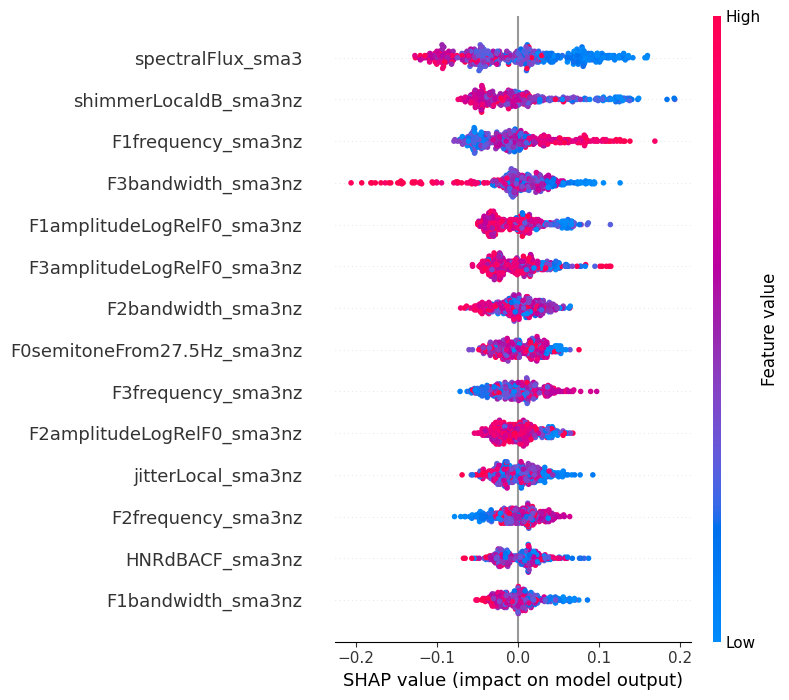

間違えたファイルの (start, end) リスト: [(79, 87), (87, 96)]
SHAP Values (error) の形状: (17, 14, 2)


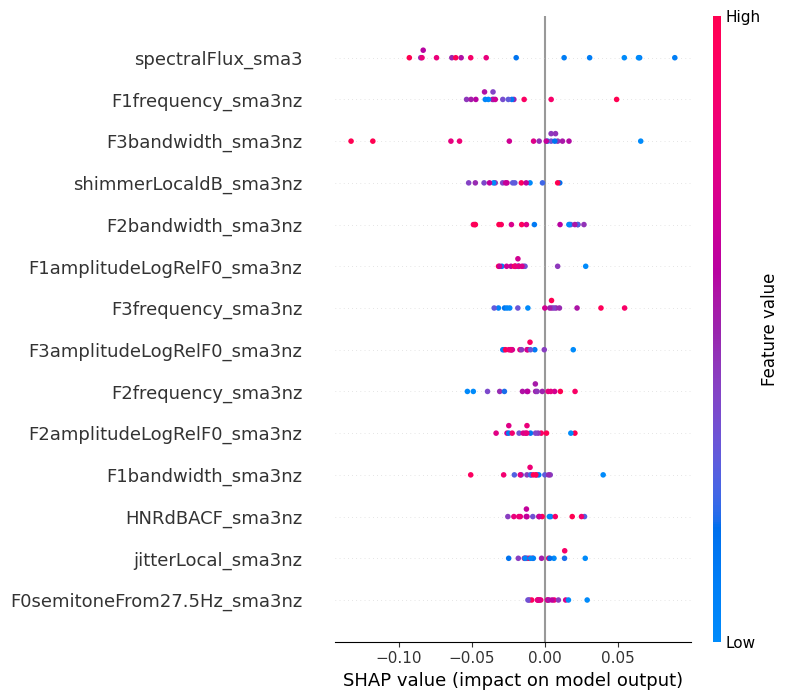

--- Fold 3 ---
訓練ファイル数: 47, テストファイル数: 12


C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\1452900565.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')
C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\1452900565.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')
C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\1452900565.py:130: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

訓練データ行数: 427
テストデータ行数: 108
訓練データの正解ラベル数: 427
テストデータの正解ラベル数: 108
0
                          filepath        filename  Delirium  Prediction
9   voice_csv_200ms\ID45_200ms.csv  ID45_200ms.csv         0         1.0
11  voice_csv_200ms\ID47_200ms.csv  ID47_200ms.csv         0         1.0
15  voice_csv_200ms\ID51_200ms.csv  ID51_200ms.csv         0         1.0
16  voice_csv_200ms\ID52_200ms.csv  ID52_200ms.csv         0         1.0
24  voice_csv_200ms\ID60_200ms.csv  ID60_200ms.csv         0         1.0
26  voice_csv_200ms\ID62_200ms.csv  ID62_200ms.csv         0         1.0
27  voice_csv_200ms\ID63_200ms.csv  ID63_200ms.csv         1         1.0
32  voice_csv_200ms\ID68_200ms.csv  ID68_200ms.csv         0         1.0
33  voice_csv_200ms\ID69_200ms.csv  ID69_200ms.csv         1         1.0
41  voice_csv_200ms\ID77_200ms.csv  ID77_200ms.csv         0         1.0
52  voice_csv_200ms\ID88_200ms.csv  ID88_200ms.csv         0         1.0
56  voice_csv_200ms\ID92_200ms.csv  ID92_200ms.csv        

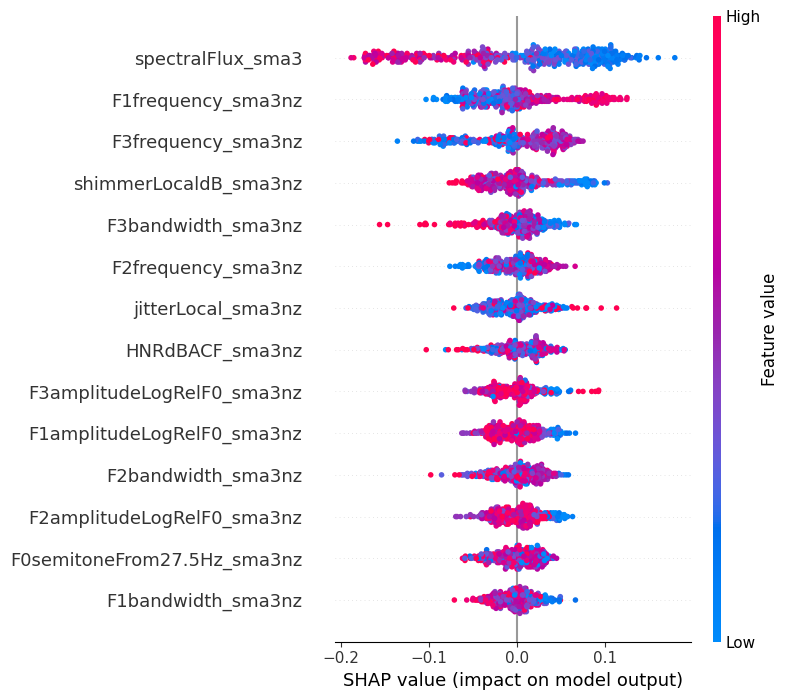

間違えたファイルの (start, end) リスト: []
該当するエラーはありませんでした。
--- Fold 4 ---
訓練ファイル数: 47, テストファイル数: 12


C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\1452900565.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')
C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\1452900565.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')
C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\1452900565.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

訓練データ行数: 420
テストデータ行数: 115
訓練データの正解ラベル数: 420
テストデータの正解ラベル数: 115
0
                          filepath        filename  Delirium  Prediction
1   voice_csv_200ms\ID37_200ms.csv  ID37_200ms.csv         0         0.0
2   voice_csv_200ms\ID38_200ms.csv  ID38_200ms.csv         0         0.0
21  voice_csv_200ms\ID57_200ms.csv  ID57_200ms.csv         1         1.0
23  voice_csv_200ms\ID59_200ms.csv  ID59_200ms.csv         0         0.0
29  voice_csv_200ms\ID65_200ms.csv  ID65_200ms.csv         1         0.0
35  voice_csv_200ms\ID71_200ms.csv  ID71_200ms.csv         1         0.0
37  voice_csv_200ms\ID73_200ms.csv  ID73_200ms.csv         0         1.0
39  voice_csv_200ms\ID75_200ms.csv  ID75_200ms.csv         1         1.0
40  voice_csv_200ms\ID76_200ms.csv  ID76_200ms.csv         1         0.0
43  voice_csv_200ms\ID79_200ms.csv  ID79_200ms.csv         1         0.0
46  voice_csv_200ms\ID82_200ms.csv  ID82_200ms.csv         1         1.0
48  voice_csv_200ms\ID84_200ms.csv  ID84_200ms.csv        

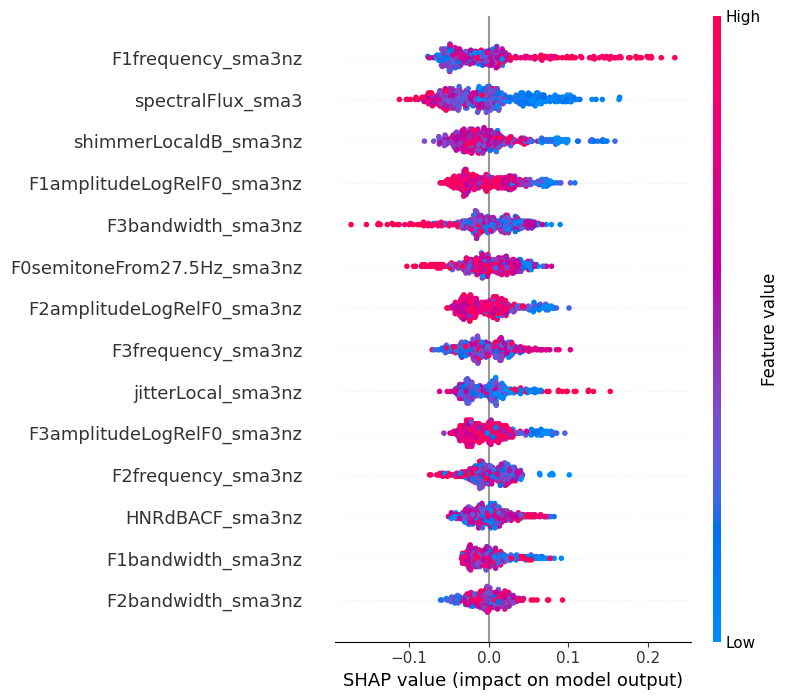

間違えたファイルの (start, end) リスト: [(40, 50), (50, 60), (79, 88), (88, 97), (106, 115)]
SHAP Values (error) の形状: (47, 14, 2)


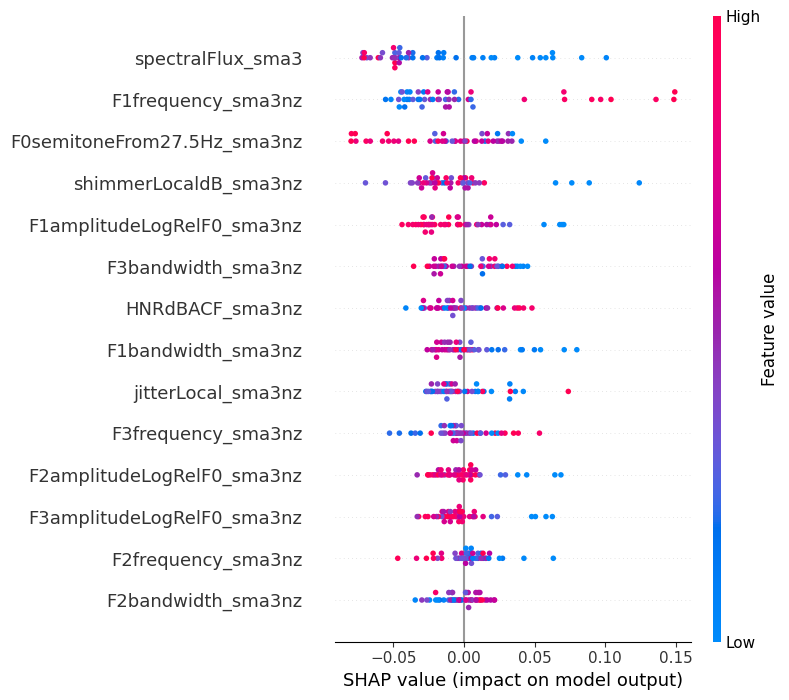

--- Fold 5 ---
訓練ファイル数: 48, テストファイル数: 11


C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\1452900565.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')
C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\1452900565.py:130: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_df2_file[col] = pd.to_numeric(max_df2_file[col], errors='coerce')
C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\1452900565.py:130: SettingWithCopyWarning: 
A value is trying to be set on a copy of

訓練データ行数: 438
テストデータ行数: 97
訓練データの正解ラベル数: 438
テストデータの正解ラベル数: 97
0
                          filepath        filename  Delirium  Prediction
7   voice_csv_200ms\ID43_200ms.csv  ID43_200ms.csv         1         0.0
10  voice_csv_200ms\ID46_200ms.csv  ID46_200ms.csv         1         1.0
14  voice_csv_200ms\ID50_200ms.csv  ID50_200ms.csv         0         0.0
18  voice_csv_200ms\ID54_200ms.csv  ID54_200ms.csv         1         0.0
20  voice_csv_200ms\ID56_200ms.csv  ID56_200ms.csv         1         0.0
22  voice_csv_200ms\ID58_200ms.csv  ID58_200ms.csv         0         1.0
28  voice_csv_200ms\ID64_200ms.csv  ID64_200ms.csv         0         0.0
38  voice_csv_200ms\ID74_200ms.csv  ID74_200ms.csv         1         0.0
42  voice_csv_200ms\ID78_200ms.csv  ID78_200ms.csv         1         0.0
51  voice_csv_200ms\ID87_200ms.csv  ID87_200ms.csv         1         1.0
58  voice_csv_200ms\ID94_200ms.csv  ID94_200ms.csv         1         1.0


このFoldの正解率 (ファイル単位): 0.4545 (5/11 ファイル正解)

混同行列:
       予測

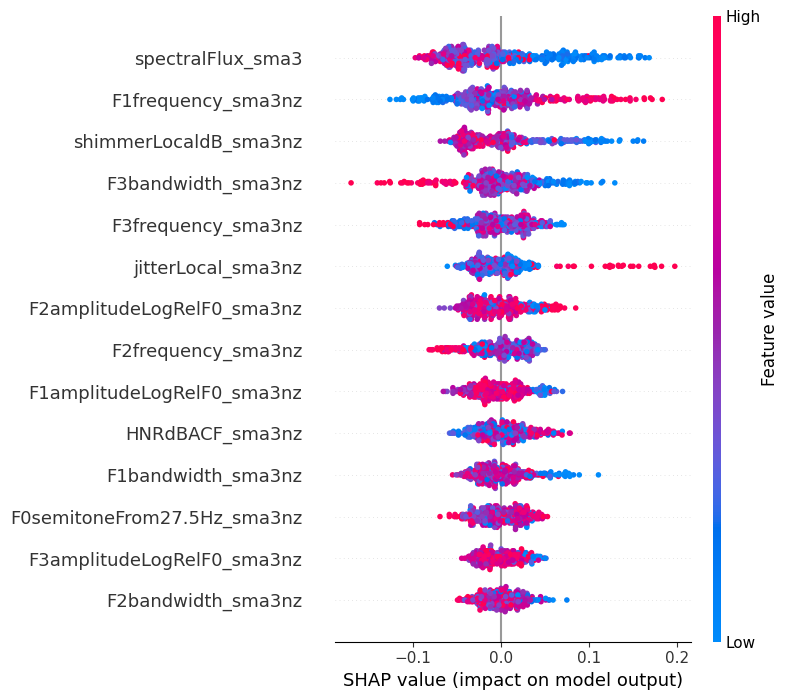

間違えたファイルの (start, end) リスト: [(0, 10), (30, 38), (38, 47), (64, 73), (73, 83)]
SHAP Values (error) の形状: (46, 14, 2)


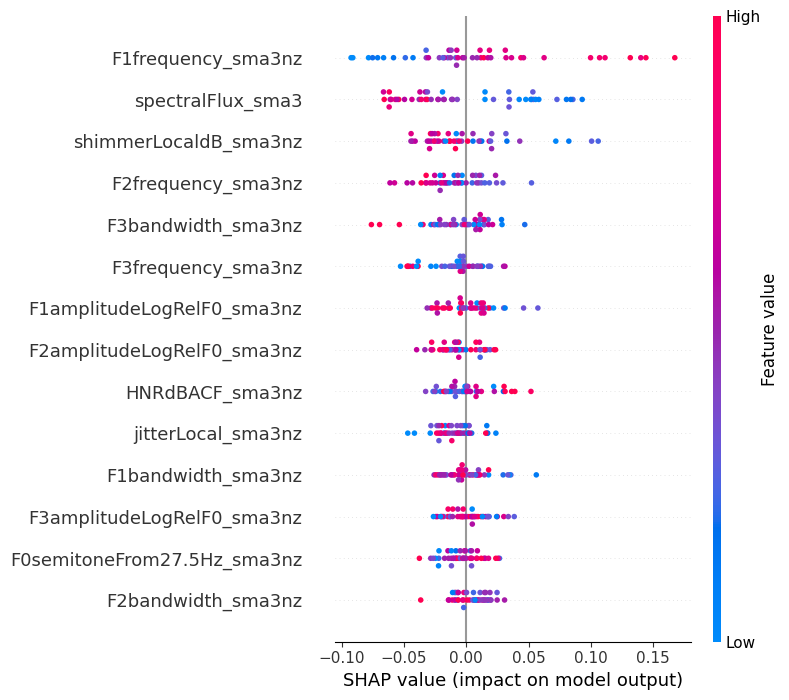

5つのFoldのファイル単位での平均正解率：0.5409

5つのFoldのファイル単位での性能のばらつき(標準偏差)：0.1904


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import os
#from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import mode
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import shap

# ファイルとdeliriumの結合
folder_path = Path('./voice_csv_200ms')
all_files = list(folder_path.glob('*.csv'))

df = pd.DataFrame({'filepath': all_files})

files_df = df 

files_df['filename'] = df['filepath'].apply(lambda p: Path(p).name)

files_df['ID'] = files_df['filename'].str.extract(r'ID(\d+)_')
files_df['ID'] = files_df['ID'].astype(int)
#print(files_df.head())

labels_df = pd.read_csv('./delirium.csv')
#print(labels_df)

file_with_labels_df = pd.merge(files_df, labels_df, on='ID', how='left')

file_with_labels_df.drop(columns=['ID', 'Sex'], inplace=True)
#print(file_with_labels_df)
#print(file_with_labels_df.columns)

#KFold Cross Validation
model = RandomForestClassifier(random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []

#CSVファイルのデータ
X_files = file_with_labels_df
#print(X_files)
#せん妄の有無(0 or 1)
y_labels = file_with_labels_df['Delirium']
#print(y_labels[2])

for fold, (train_indices, test_indices) in enumerate(kf.split(X_files)):

    train_files = X_files.iloc[train_indices]
    test_files = X_files.iloc[test_indices]

    print(f"--- Fold {fold+1} ---")
    print(f"訓練ファイル数: {len(train_files)}, テストファイル数: {len(test_files)}")

    #print(test_files)

    train_files_path = [folder_path / fname for fname in train_files['filename']]
    test_files_path = [folder_path / fname for fname in test_files['filename']]
    #print(train_files_path)
    train_df = pd.DataFrame()
    test_df = pd.DataFrame()
    for f in train_files_path:
        #df_train_file = pd.read_csv(f).iloc[::2]
        df_train_file = pd.read_csv(f)

        #print(f)
        current_filename = os.path.basename(f)
        #print(current_filename)
        rows = train_files[train_files['filename'] == current_filename]
        #print(rows)
        file_delirium = rows['Delirium'].iloc[0]
        #print(file_delirium)
        df_train_file['Delirium'] = file_delirium
        df_train_file['filename'] = current_filename
        #print(df_train_file)

        #df_train_file['Delirium'] = train_files[train_files['filename'] == current_filename]['Delirium'].iloc[2]
        
        #delete space
        df_train_file['label'] = df_train_file['label'].str.strip()
        #only answer1-10
        max_df1 = df_train_file[df_train_file["label"].str.match('^answer(10|[1-9])$', na=False)]
        #max_df1_file.info()
        
        max_df1_file = max_df1.dropna()

        columns_to_convert = ['start', 'end', 'original_start', 'original_end', 'filename']

        # forループを使って、指定した列を順番に数値型に変換
        for col in columns_to_convert:
            max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')

        #max_df1_file.info()

        max_df_train_file = max_df1_file.groupby('label').mean()
        #print(max_df_train_file)

        max_df_train_file = max_df_train_file.reset_index()

        train_df = pd.concat([train_df, max_df_train_file], ignore_index=True)
    #train_df.to_csv('output.csv', index=False, encoding='utf-8-sig')
    test_file_lengths = []
    for f in test_files_path:
        #df_test_file = pd.read_csv(f).iloc[::2]
        df_test_file = pd.read_csv(f)

        #print(f)
        current_filename = os.path.basename(f)
        #print(current_filename)
        rows = test_files[test_files['filename'] == current_filename]
        #print(rows)
        file_delirium = rows['Delirium'].iloc[0]
        #print(file_delirium)
        df_test_file['Delirium'] = file_delirium
        df_test_file['filename'] = current_filename

        #delete space
        df_test_file['label'] = df_test_file['label'].str.strip()
        #only answer1-10
        max_df2 = df_test_file[df_test_file["label"].str.match('^answer(10|[1-9])$', na=False)]

        max_df2_file = max_df2.dropna()

        columns_to_convert = ['start', 'end', 'original_start', 'original_end', 'filename']

        # forループを使って、指定した列を順番に数値型に変換
        for col in columns_to_convert:
            max_df2_file[col] = pd.to_numeric(max_df2_file[col], errors='coerce')

        max_df_test_file = max_df2_file.groupby('label').mean()
        max_df_test_file = max_df_test_file.reset_index()

        test_file_lengths.append(len(max_df_test_file))

        test_df = pd.concat([test_df, max_df_test_file], ignore_index=True)
    #test_df.to_csv('output.csv', index=False, encoding='utf-8-sig')
    #print(train_df)
    #print(test_df)


    #train_df = pd.concat([pd.read_csv(f).iloc[::2] for f in train_files_path], ignore_index=True)
    #test_df = pd.concat([pd.read_csv(f).iloc[::2] for f in test_files_path], ignore_index=True)

    #train_df = pd.concat([pd.read_csv(f) for f in train_files_path], ignore_index=True)
    #test_df = pd.concat([pd.read_csv(f) for f in test_files_path], ignore_index=True)
    #print(train_df)
    #print(test_df)

    print(f"訓練データ行数: {len(train_df)}")
    #train_df = train_df.iloc[::2]
    #train_df = train_df.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(train_df)}")

    print(f"テストデータ行数: {len(test_df)}")
    #test_df = test_df.iloc[::2]
    #test_df = test_df.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(test_df)}")


    columns_drop = ['start', 'end', 'label', 'alphaRatio_sma3', 'hammarbergIndex_sma3', 'slope0-500_sma3', 'slope500-1500_sma3', 'mfcc1_sma3', 'mfcc2_sma3', 'mfcc3_sma3', 'mfcc4_sma3','Loudness_sma3', 'logRelF0-H1-H2_sma3nz', 'logRelF0-H1-A3_sma3nz', 'original_start', 'original_end', 'Delirium', 'filename']
    #,'Loudness_sma3'

    #print(train_indices)
    #print(test_indices)

    #y_train = y_labels.iloc[train_indices].repeat([len(pd.read_csv(f)) for f in train_files_path])
    #y_test = y_labels.iloc[test_indices].repeat([len(pd.read_csv(f)) for f in test_files_path])
    #print(y_train)

    #print(f"元の訓練データ行数: {len(y_train)}")
    #y_train = y_train.iloc[::2]
    #y_train = y_train.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(y_train)}")

    #print(f"元のテストデータ行数: {len(y_test)}")
    #y_test = y_test.iloc[::2]
    #y_test = y_test.reset_index(drop=True)
    #print(f"間引き後のテストデータ行数: {len(y_test)}")

    y_train = train_df['Delirium']
    #print(y_train)
    y_test = test_df['Delirium']
    #print(y_test)
    X_train = train_df.drop(columns=columns_drop, errors='ignore')
    X_test = test_df.drop(columns=columns_drop, errors='ignore')

    print(f"訓練データの正解ラベル数: {len(y_train)}")
    print(f"テストデータの正解ラベル数: {len(y_test)}")

    #print(X_train)

    #NaNの数をカウント
    print(y_train.isnull().sum())

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_true = y_test
    #print(y_pred)

    file_predictions = []

    # 各テストファイルの行数を事前に計算しておく

    #test_file_lengths = [len(pd.read_csv(f).iloc[::2]) for f in test_files_path]
    #print(test_file_lengths)

    start_idx = 0
    for length in test_file_lengths:
        end_idx = start_idx + length
        #print(start_idx, end_idx)
        predictions_for_this_file = y_pred[start_idx:end_idx]
        #print(predictions_for_this_file)
        majority_vote = mode(predictions_for_this_file)[0]
        #print(majority_vote)
        file_predictions.append([majority_vote, start_idx, end_idx])
        start_idx = end_idx

    first_column_list = [item[0] for item in file_predictions]

    #print(file_predictions)

    y_test_files = test_files['Delirium'].values

    #print(y_test_files)

    test_files_copy = test_files
    #test_files_copy['Predict'] = file_predictions
    test_files_copy = test_files_copy.assign(Prediction=first_column_list)

    print(test_files_copy)

    correct_files = np.sum(np.array(first_column_list) == y_test_files)
    total_files = len(test_files)
    accuracy = correct_files/ total_files

    scores.append(accuracy)
    print("\n")
    print(f"このFoldの正解率 (ファイル単位): {accuracy:.4f} ({correct_files}/{total_files} ファイル正解)\n")

    # 4-2. 混同行列の計算
    # y_test_files (正解ラベル) と file_predictions (予測ラベル) を渡す
    cm = confusion_matrix(y_test_files, first_column_list)

    # 4-3. 見やすいようにDataFrameに変換して表示
    # ラベルが0と1の場合
    cm_df = pd.DataFrame(cm, 
                     index=['正解: 0', '正解: 1'], 
                     columns=['予測: 0', '予測: 1'])

    print("混同行列:")
    print(cm_df)
    print("\n") # 見やすいように改行

    #特徴量の重要度を取得
    feature_names = X_train.columns.tolist()
    
    importances = model.feature_importances_

    #特徴量の名前と重要度をまとめたDataFrameを作成
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    #重要度が高い順にソート
    sorted_importance_df = importance_df.sort_values(by='Importance', ascending=False)

    print(sorted_importance_df)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train) 

    #shap_values 全体の形状を確認 (おそらく (479, 14, 2))
    print(f"SHAP Values (全体) の形状: {shap_values.shape}")

    #せん妄ありのSHAP値だけをスライス ---
    shap_values_class1 = shap_values[:, :, 1]

    #スライスした後の形状を確認 (これで (479, 14) になるはず)
    print(f"SHAP Values (Class 1) の形状: {shap_values_class1.shape}")
    #print(f"X_train の形状: {X_train.shape}")

    #スライスした shap_values_class1 を渡す
    shap.summary_plot(shap_values_class1, X_train)

    #予測が0で正解が1の場合
    shap.initjs()

    misclassified_indices = []

    for pred, true_label, full_item in zip(first_column_list, y_test_files, file_predictions):

        if (pred == 0) & (true_label == 1):
            start_idx = full_item[1]
            end_idx = full_item[2]

            misclassified_indices.append((start_idx, end_idx))

    print(f"間違えたファイルの (start, end) リスト: {misclassified_indices}")

    #間違えたセグメントを格納するための空のリスト
    X_test_errors_list = []

    for start, end in misclassified_indices:
        #X_test から start から end までのセグメントをスライス
        #(iloc は X_test がDataFrameの場合。Numpy配列なら X_test[start:end] )
        segment = X_test.iloc[start:end] 
        X_test_errors_list.append(segment)

    #抜き出したセグメントをすべて結合
    if X_test_errors_list:
        X_test_errors = pd.concat(X_test_errors_list) #DataFrameの場合
        
        #これで初めて X_test_errors に対して SHAP が実行できる
        shap_values_errors = explainer.shap_values(X_test_errors)
        
        print(f"SHAP Values (error) の形状: {shap_values_errors.shape}")
        shap.summary_plot(shap_values_errors[:, :, 1], X_test_errors)
    else:
        print("該当するエラーはありませんでした。")

    #特徴量ごとの散布図を比較
    #feature_name = 'Loudness_sma3'

    #fig, (sp1, sp2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    #fig.suptitle(f'{feature_name}', fontsize=16)

    #sp1.scatter(range(len(X_train)), X_train[feature_name], alpha=0.6)
    #sp1.set_title('train data')
    #sp1.set_xlabel('index')
    #sp1.set_ylabel(feature_name)
    #sp1.grid(True)

    #sp2.scatter(range(len(X_test)), X_test[feature_name], alpha=0.6)
    #sp2.set_title('test data')
    #sp2.set_xlabel('index')
    #sp2.set_ylabel(feature_name)
    #sp2.grid(True)

    #グラフを表示
    #plt.tight_layout(rect=[0, 0.03, 1, 0.95])a
    #plt.show()

    

total_accuracy = sum(scores) / len(scores)
print(f"5つのFoldのファイル単位での平均正解率：{total_accuracy:.4f}\n")
print(f"5つのFoldのファイル単位での性能のばらつき(標準偏差)：{np.std(scores):.4f}")

SHAP Values (全体) の形状: (479, 14, 2)
SHAP Values (Class 1) の形状: (479, 14)
X_train の形状: (479, 14)


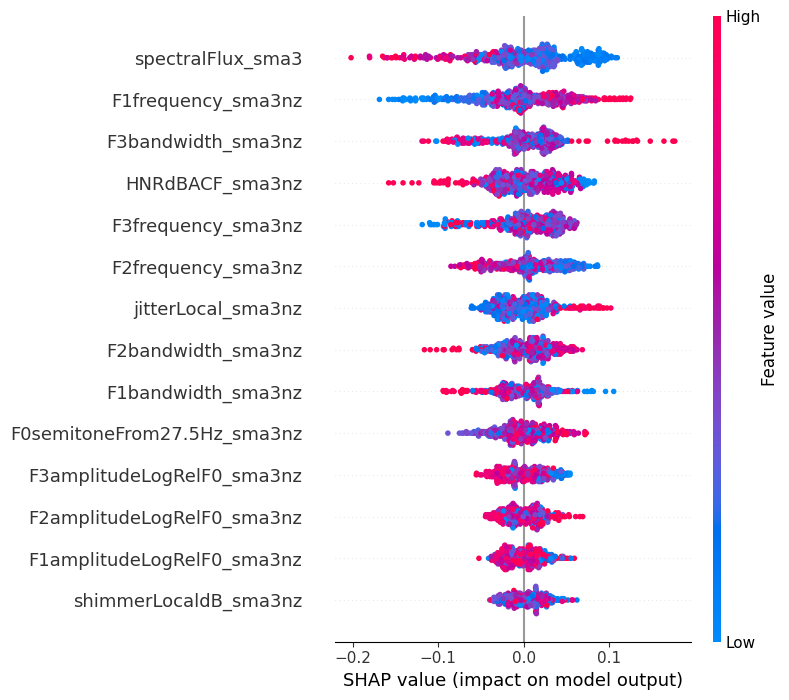

In [50]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train) 

# shap_values 全体の形状を確認 (おそらく (479, 14, 2))
print(f"SHAP Values (全体) の形状: {shap_values.shape}")

# --- Class 1 のSHAP値だけをスライス ---
shap_values_class1 = shap_values[:, :, 1]

# スライスした後の形状を確認 (これで (479, 14) になるはず)
print(f"SHAP Values (Class 1) の形状: {shap_values_class1.shape}")
print(f"X_train の形状: {X_train.shape}")


# --- summary_plot を実行 ---
# スライスした shap_values_class1 を渡す
shap.summary_plot(shap_values_class1, X_train)
#shap.summary_plot(shap_values_class1, X_test, plot_type="bar")

結果の分析

SHAP Values (error) の形状: (16, 14, 2)
ID58, 68


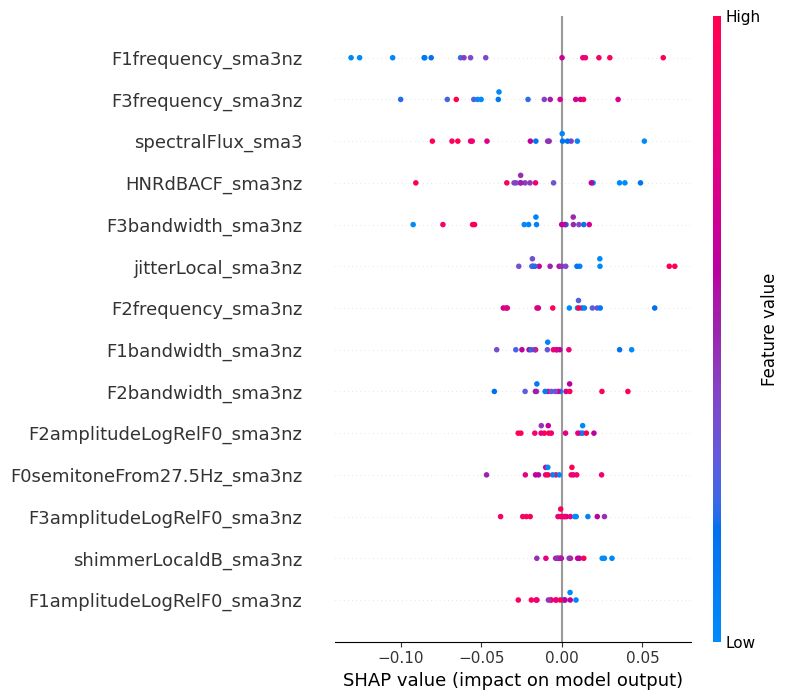

In [49]:
shap.initjs()

misclassified_mask = (y_pred == 0) & (y_true ==1)

X_test_errors = X_test[misclassified_mask]

y_test_errors = y_true[misclassified_mask]

shap_values_errors = explainer.shap_values(X_test_errors)

print(f"SHAP Values (error) の形状: {shap_values_errors.shape}")
print("ID58, 68")

shap.summary_plot(shap_values_errors[:, :, 1], X_test_errors)



In [51]:
# 'model' は学習済みのランダムフォレストモデル
print(f"モデルが認識しているクラスの順序: {model.classes_}")

モデルが認識しているクラスの順序: [0. 1.]


In [46]:
shap.force_plot(
    explainer.expected_value[1],     # クラス1の基準値
    shap_values_errors[0, :, 1],     # 不正解1件目 の クラス1 SHAP値
    X_test_errors.iloc[0, :]         # 不正解1件目 の 元の値
)

層化クロスバリデーション

--- Fold 1 ---
訓練ファイル数: 47, テストファイル数: 12


C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\3885051487.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')
C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\3885051487.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')
C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\3885051487.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

訓練データ行数: 423
テストデータ行数: 112
訓練データの正解ラベル数: 423
テストデータの正解ラベル数: 112
0
                          filepath        filename  Delirium  Prediction
4   voice_csv_200ms\ID40_200ms.csv  ID40_200ms.csv         0         0.0
7   voice_csv_200ms\ID43_200ms.csv  ID43_200ms.csv         1         0.0
8   voice_csv_200ms\ID44_200ms.csv  ID44_200ms.csv         1         1.0
15  voice_csv_200ms\ID51_200ms.csv  ID51_200ms.csv         0         1.0
16  voice_csv_200ms\ID52_200ms.csv  ID52_200ms.csv         0         1.0
17  voice_csv_200ms\ID53_200ms.csv  ID53_200ms.csv         0         0.0
19  voice_csv_200ms\ID55_200ms.csv  ID55_200ms.csv         0         1.0
24  voice_csv_200ms\ID60_200ms.csv  ID60_200ms.csv         0         0.0
35  voice_csv_200ms\ID71_200ms.csv  ID71_200ms.csv         1         0.0
36  voice_csv_200ms\ID72_200ms.csv  ID72_200ms.csv         1         1.0
43  voice_csv_200ms\ID79_200ms.csv  ID79_200ms.csv         1         0.0
44  voice_csv_200ms\ID80_200ms.csv  ID80_200ms.csv        

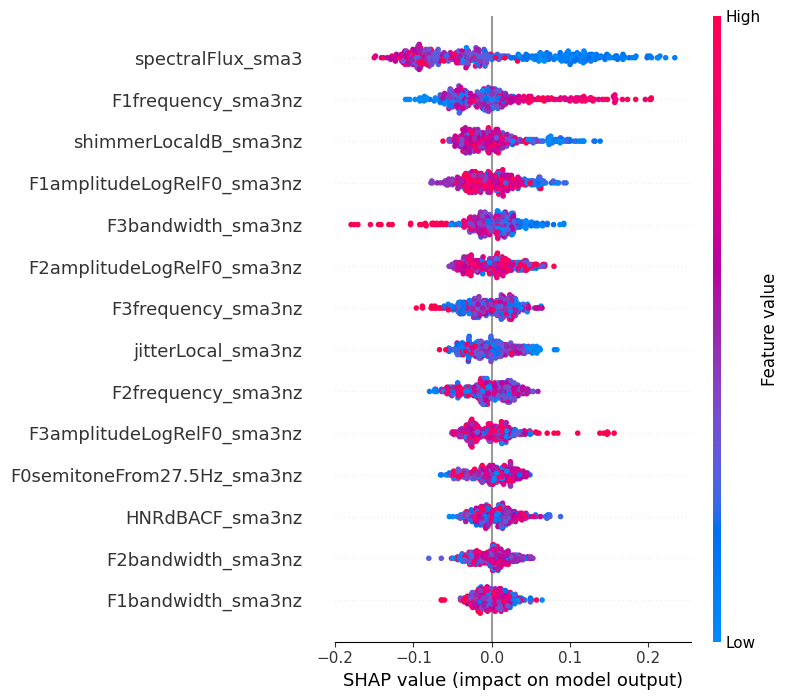

間違えたファイルの (start, end) リスト: [(10, 20), (75, 85), (93, 102)]
SHAP Values (error) の形状: (29, 14, 2)


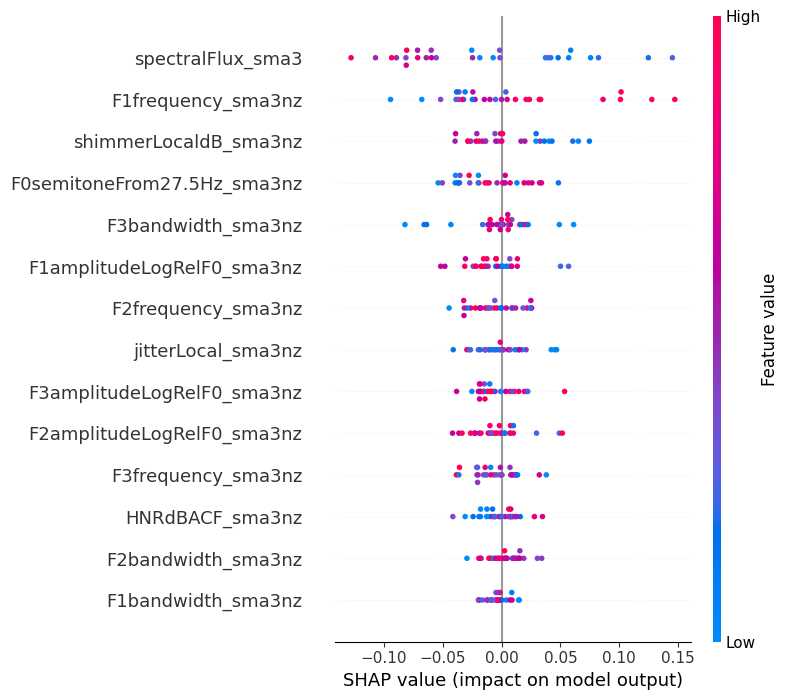

--- Fold 2 ---
訓練ファイル数: 47, テストファイル数: 12


C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\3885051487.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')
C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\3885051487.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')
C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\3885051487.py:130: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

訓練データ行数: 424
テストデータ行数: 111
訓練データの正解ラベル数: 424
テストデータの正解ラベル数: 111
0
                          filepath        filename  Delirium  Prediction
0   voice_csv_200ms\ID36_200ms.csv  ID36_200ms.csv         0         0.0
2   voice_csv_200ms\ID38_200ms.csv  ID38_200ms.csv         0         0.0
11  voice_csv_200ms\ID47_200ms.csv  ID47_200ms.csv         0         0.0
20  voice_csv_200ms\ID56_200ms.csv  ID56_200ms.csv         1         0.0
29  voice_csv_200ms\ID65_200ms.csv  ID65_200ms.csv         1         0.0
32  voice_csv_200ms\ID68_200ms.csv  ID68_200ms.csv         0         0.0
37  voice_csv_200ms\ID73_200ms.csv  ID73_200ms.csv         0         1.0
39  voice_csv_200ms\ID75_200ms.csv  ID75_200ms.csv         1         1.0
42  voice_csv_200ms\ID78_200ms.csv  ID78_200ms.csv         1         0.0
51  voice_csv_200ms\ID87_200ms.csv  ID87_200ms.csv         1         1.0
53  voice_csv_200ms\ID89_200ms.csv  ID89_200ms.csv         0         0.0
57  voice_csv_200ms\ID93_200ms.csv  ID93_200ms.csv        

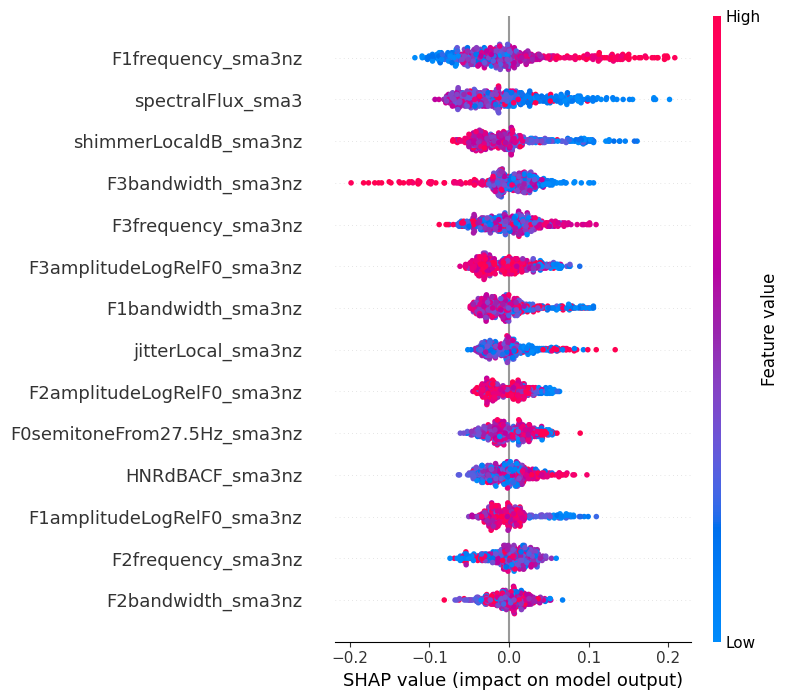

間違えたファイルの (start, end) リスト: [(30, 39), (39, 49), (76, 86)]
SHAP Values (error) の形状: (29, 14, 2)


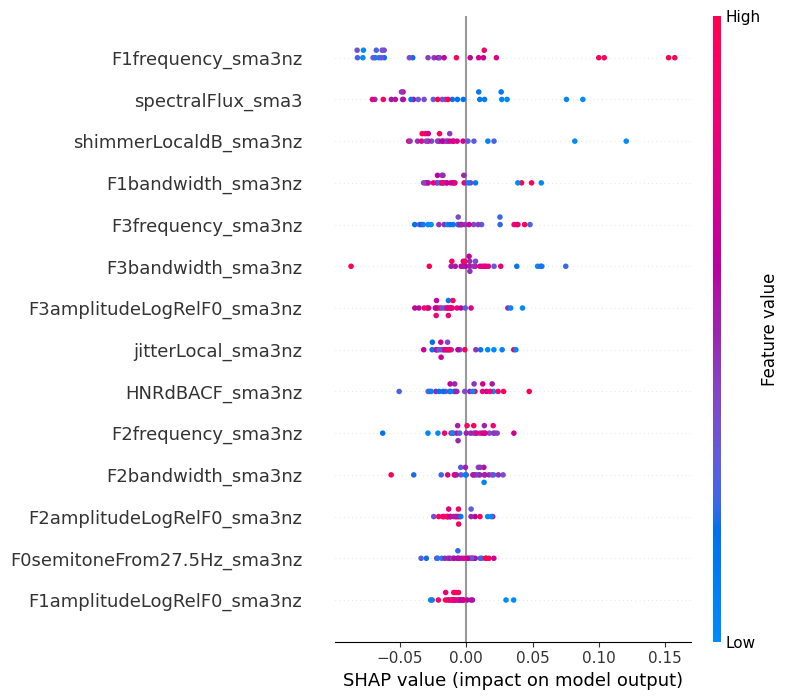

--- Fold 3 ---
訓練ファイル数: 47, テストファイル数: 12


C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\3885051487.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')
C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\3885051487.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')
C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\3885051487.py:130: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

訓練データ行数: 427
テストデータ行数: 108
訓練データの正解ラベル数: 427
テストデータの正解ラベル数: 108
0
                          filepath        filename  Delirium  Prediction
5   voice_csv_200ms\ID41_200ms.csv  ID41_200ms.csv         0         0.0
6   voice_csv_200ms\ID42_200ms.csv  ID42_200ms.csv         0         0.0
12  voice_csv_200ms\ID48_200ms.csv  ID48_200ms.csv         1         1.0
13  voice_csv_200ms\ID49_200ms.csv  ID49_200ms.csv         0         0.0
14  voice_csv_200ms\ID50_200ms.csv  ID50_200ms.csv         0         0.0
22  voice_csv_200ms\ID58_200ms.csv  ID58_200ms.csv         0         1.0
33  voice_csv_200ms\ID69_200ms.csv  ID69_200ms.csv         1         1.0
40  voice_csv_200ms\ID76_200ms.csv  ID76_200ms.csv         1         0.0
41  voice_csv_200ms\ID77_200ms.csv  ID77_200ms.csv         0         0.0
49  voice_csv_200ms\ID85_200ms.csv  ID85_200ms.csv         1         0.0
50  voice_csv_200ms\ID86_200ms.csv  ID86_200ms.csv         1         0.0
55  voice_csv_200ms\ID91_200ms.csv  ID91_200ms.csv        

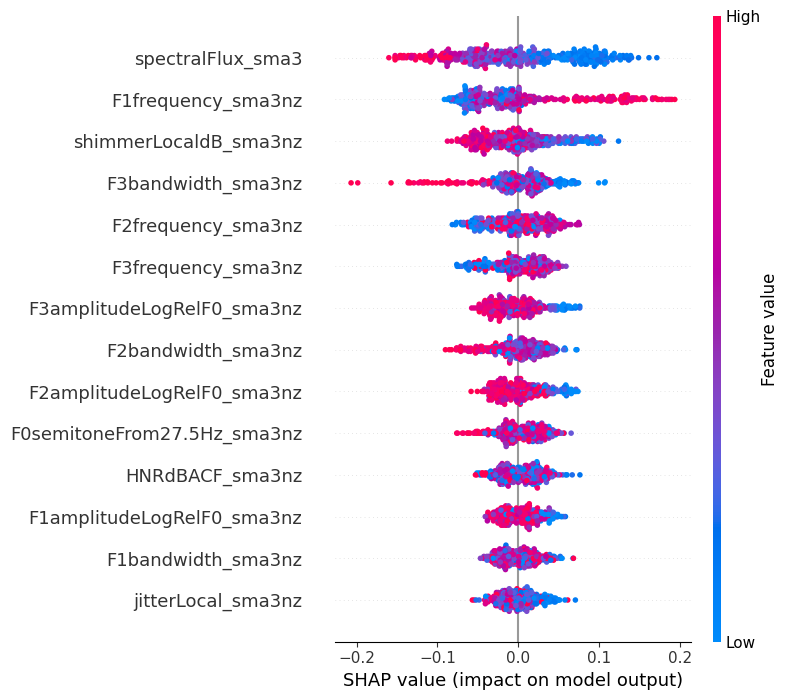

間違えたファイルの (start, end) リスト: [(65, 74), (82, 91), (91, 99), (99, 108)]
SHAP Values (error) の形状: (35, 14, 2)


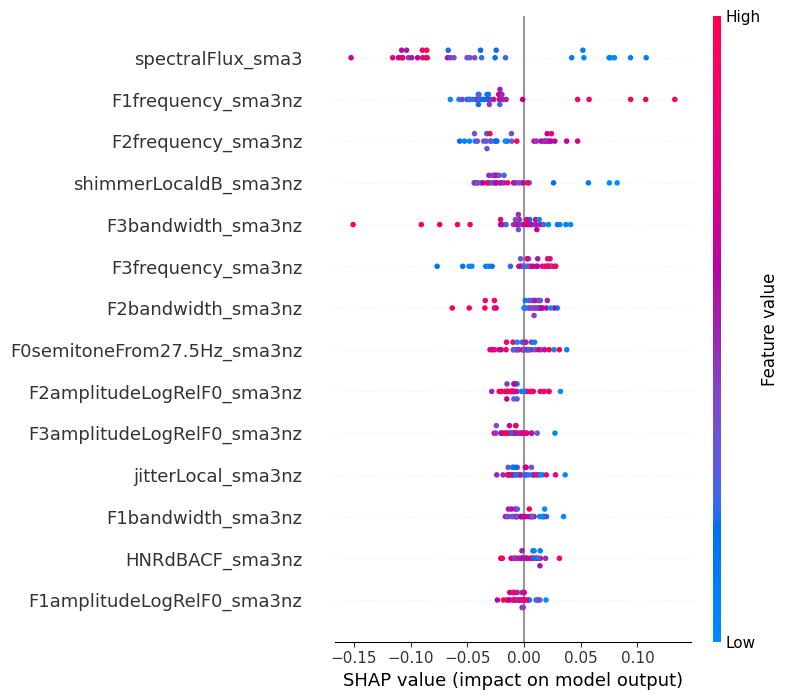

--- Fold 4 ---
訓練ファイル数: 47, テストファイル数: 12


C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\3885051487.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')
C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\3885051487.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')
C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\3885051487.py:130: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

訓練データ行数: 431
テストデータ行数: 104
訓練データの正解ラベル数: 431
テストデータの正解ラベル数: 104
0
                          filepath        filename  Delirium  Prediction
3   voice_csv_200ms\ID39_200ms.csv  ID39_200ms.csv         0         0.0
9   voice_csv_200ms\ID45_200ms.csv  ID45_200ms.csv         0         0.0
10  voice_csv_200ms\ID46_200ms.csv  ID46_200ms.csv         1         1.0
18  voice_csv_200ms\ID54_200ms.csv  ID54_200ms.csv         1         1.0
28  voice_csv_200ms\ID64_200ms.csv  ID64_200ms.csv         0         0.0
31  voice_csv_200ms\ID67_200ms.csv  ID67_200ms.csv         0         1.0
34  voice_csv_200ms\ID70_200ms.csv  ID70_200ms.csv         1         1.0
45  voice_csv_200ms\ID81_200ms.csv  ID81_200ms.csv         1         1.0
47  voice_csv_200ms\ID83_200ms.csv  ID83_200ms.csv         1         0.0
48  voice_csv_200ms\ID84_200ms.csv  ID84_200ms.csv         1         1.0
52  voice_csv_200ms\ID88_200ms.csv  ID88_200ms.csv         0         0.0
56  voice_csv_200ms\ID92_200ms.csv  ID92_200ms.csv        

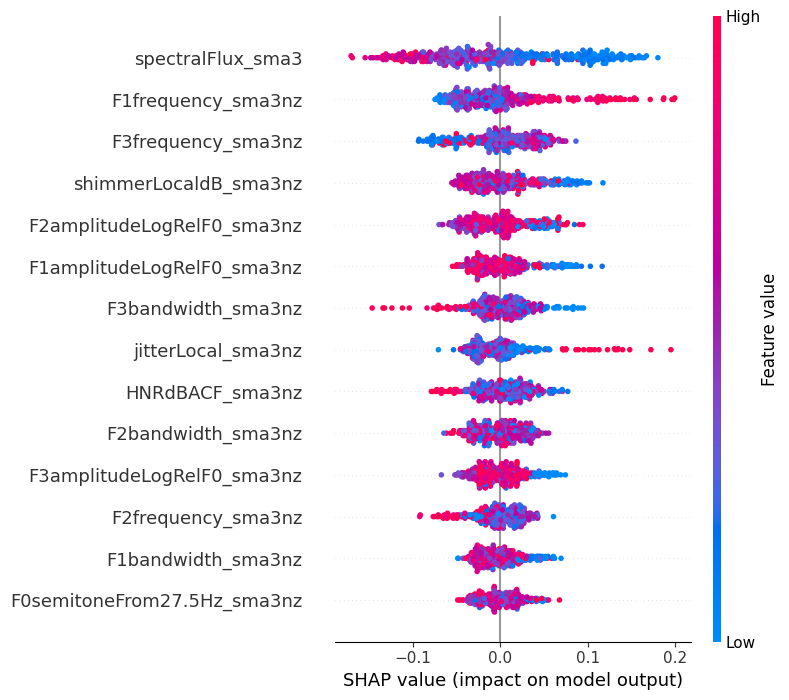

間違えたファイルの (start, end) リスト: [(69, 77), (95, 104)]
SHAP Values (error) の形状: (17, 14, 2)


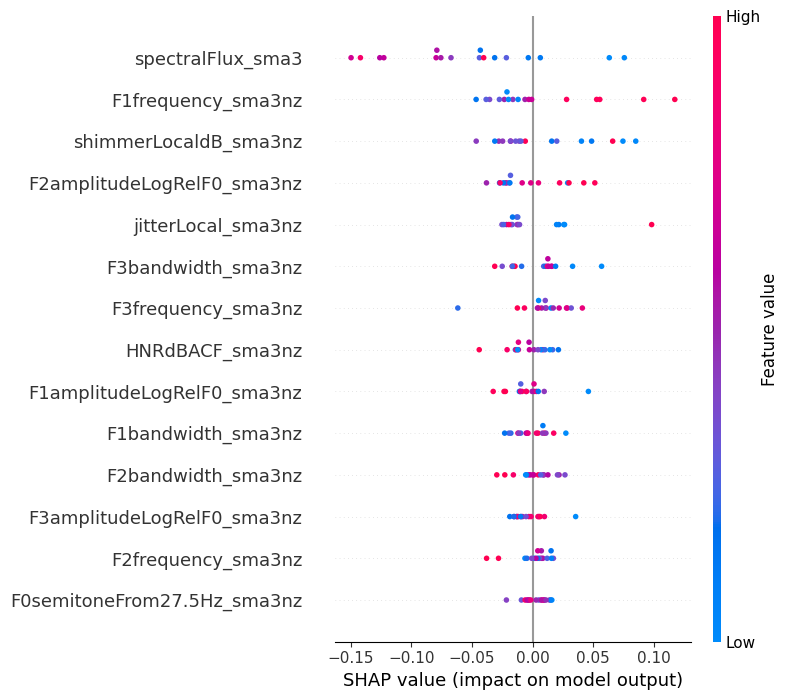

--- Fold 5 ---
訓練ファイル数: 48, テストファイル数: 11


C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\3885051487.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')
C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\3885051487.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')
C:\Users\robotics\AppData\Local\Temp\ipykernel_22024\3885051487.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

訓練データ行数: 435
テストデータ行数: 100
訓練データの正解ラベル数: 435
テストデータの正解ラベル数: 100
0
                          filepath        filename  Delirium  Prediction
1   voice_csv_200ms\ID37_200ms.csv  ID37_200ms.csv         0         0.0
21  voice_csv_200ms\ID57_200ms.csv  ID57_200ms.csv         1         1.0
23  voice_csv_200ms\ID59_200ms.csv  ID59_200ms.csv         0         0.0
25  voice_csv_200ms\ID61_200ms.csv  ID61_200ms.csv         0         0.0
26  voice_csv_200ms\ID62_200ms.csv  ID62_200ms.csv         0         0.0
27  voice_csv_200ms\ID63_200ms.csv  ID63_200ms.csv         1         1.0
30  voice_csv_200ms\ID66_200ms.csv  ID66_200ms.csv         0         0.0
38  voice_csv_200ms\ID74_200ms.csv  ID74_200ms.csv         1         0.0
46  voice_csv_200ms\ID82_200ms.csv  ID82_200ms.csv         1         1.0
54  voice_csv_200ms\ID90_200ms.csv  ID90_200ms.csv         1         0.0
58  voice_csv_200ms\ID94_200ms.csv  ID94_200ms.csv         1         1.0


このFoldの正解率 (ファイル単位): 0.8182 (9/11 ファイル正解)

混同行列:
       

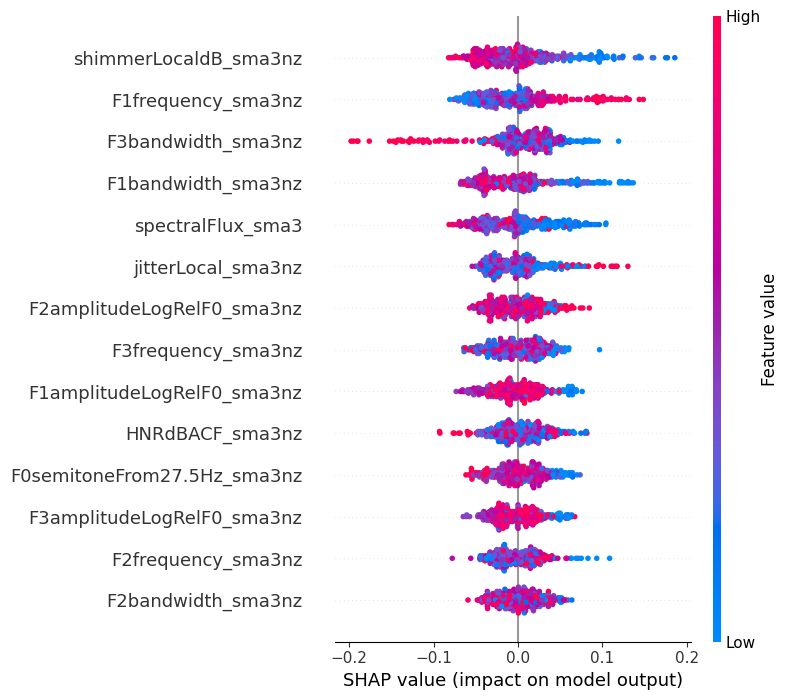

間違えたファイルの (start, end) リスト: [(66, 75), (84, 93)]
SHAP Values (error) の形状: (18, 14, 2)


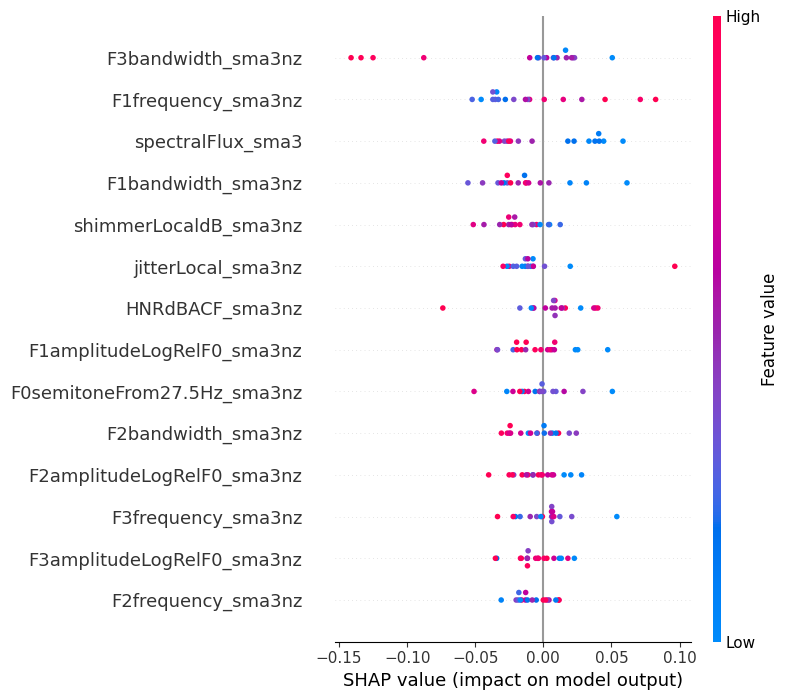

5つのFoldのファイル単位での平均正解率：0.6636

5つのFoldのファイル単位での性能のばらつき(標準偏差)：0.1136


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import os
#from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import mode
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import shap

# ファイルとdeliriumの結合
folder_path = Path('./voice_csv_200ms')
all_files = list(folder_path.glob('*.csv'))

df = pd.DataFrame({'filepath': all_files})

files_df = df 

files_df['filename'] = df['filepath'].apply(lambda p: Path(p).name)

files_df['ID'] = files_df['filename'].str.extract(r'ID(\d+)_')
files_df['ID'] = files_df['ID'].astype(int)
#print(files_df.head())

labels_df = pd.read_csv('./delirium.csv')
#print(labels_df)

file_with_labels_df = pd.merge(files_df, labels_df, on='ID', how='left')

file_with_labels_df.drop(columns=['ID', 'Sex'], inplace=True)
#print(file_with_labels_df)
#print(file_with_labels_df.columns)

#KFold Cross Validation
model = RandomForestClassifier(random_state=42)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

#CSVファイルのデータ
X_files = file_with_labels_df
#print(X_files)
#せん妄の有無(0 or 1)
y_labels = file_with_labels_df['Delirium']
#print(y_labels[2])

for fold, (train_indices, test_indices) in enumerate(kf.split(X_files, y_labels)):

    train_files = X_files.iloc[train_indices]
    test_files = X_files.iloc[test_indices]

    print(f"--- Fold {fold+1} ---")
    print(f"訓練ファイル数: {len(train_files)}, テストファイル数: {len(test_files)}")

    #print(test_files)

    train_files_path = [folder_path / fname for fname in train_files['filename']]
    test_files_path = [folder_path / fname for fname in test_files['filename']]
    #print(train_files_path)
    train_df = pd.DataFrame()
    test_df = pd.DataFrame()
    for f in train_files_path:
        #df_train_file = pd.read_csv(f).iloc[::2]
        df_train_file = pd.read_csv(f)

        #print(f)
        current_filename = os.path.basename(f)
        #print(current_filename)
        rows = train_files[train_files['filename'] == current_filename]
        #print(rows)
        file_delirium = rows['Delirium'].iloc[0]
        #print(file_delirium)
        df_train_file['Delirium'] = file_delirium
        df_train_file['filename'] = current_filename
        #print(df_train_file)

        #df_train_file['Delirium'] = train_files[train_files['filename'] == current_filename]['Delirium'].iloc[2]
        
        #delete space
        df_train_file['label'] = df_train_file['label'].str.strip()
        #only answer1-10
        max_df1 = df_train_file[df_train_file["label"].str.match('^answer(10|[1-9])$', na=False)]
        #max_df1_file.info()
        
        max_df1_file = max_df1.dropna()

        columns_to_convert = ['start', 'end', 'original_start', 'original_end', 'filename']

        # forループを使って、指定した列を順番に数値型に変換
        for col in columns_to_convert:
            max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')

        #max_df1_file.info()

        max_df_train_file = max_df1_file.groupby('label').mean()
        #print(max_df_train_file)

        max_df_train_file = max_df_train_file.reset_index()

        train_df = pd.concat([train_df, max_df_train_file], ignore_index=True)
    #train_df.to_csv('output.csv', index=False, encoding='utf-8-sig')
    test_file_lengths = []
    for f in test_files_path:
        #df_test_file = pd.read_csv(f).iloc[::2]
        df_test_file = pd.read_csv(f)

        #print(f)
        current_filename = os.path.basename(f)
        #print(current_filename)
        rows = test_files[test_files['filename'] == current_filename]
        #print(rows)
        file_delirium = rows['Delirium'].iloc[0]
        #print(file_delirium)
        df_test_file['Delirium'] = file_delirium
        df_test_file['filename'] = current_filename

        #delete space
        df_test_file['label'] = df_test_file['label'].str.strip()
        #only answer1-10
        max_df2 = df_test_file[df_test_file["label"].str.match('^answer(10|[1-9])$', na=False)]

        max_df2_file = max_df2.dropna()

        columns_to_convert = ['start', 'end', 'original_start', 'original_end', 'filename']

        # forループを使って、指定した列を順番に数値型に変換
        for col in columns_to_convert:
            max_df2_file[col] = pd.to_numeric(max_df2_file[col], errors='coerce')

        max_df_test_file = max_df2_file.groupby('label').mean()
        max_df_test_file = max_df_test_file.reset_index()

        test_file_lengths.append(len(max_df_test_file))

        test_df = pd.concat([test_df, max_df_test_file], ignore_index=True)
    #test_df.to_csv('output.csv', index=False, encoding='utf-8-sig')
    #print(train_df)
    #print(test_df)


    #train_df = pd.concat([pd.read_csv(f).iloc[::2] for f in train_files_path], ignore_index=True)
    #test_df = pd.concat([pd.read_csv(f).iloc[::2] for f in test_files_path], ignore_index=True)

    #train_df = pd.concat([pd.read_csv(f) for f in train_files_path], ignore_index=True)
    #test_df = pd.concat([pd.read_csv(f) for f in test_files_path], ignore_index=True)
    #print(train_df)
    #print(test_df)

    print(f"訓練データ行数: {len(train_df)}")
    #train_df = train_df.iloc[::2]
    #train_df = train_df.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(train_df)}")

    print(f"テストデータ行数: {len(test_df)}")
    #test_df = test_df.iloc[::2]
    #test_df = test_df.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(test_df)}")


    columns_drop = ['start', 'end', 'label', 'alphaRatio_sma3', 'hammarbergIndex_sma3', 'slope0-500_sma3', 'slope500-1500_sma3', 'mfcc1_sma3', 'mfcc2_sma3', 'mfcc3_sma3', 'mfcc4_sma3','Loudness_sma3', 'logRelF0-H1-H2_sma3nz', 'logRelF0-H1-A3_sma3nz', 'original_start', 'original_end', 'Delirium', 'filename']
    #,'Loudness_sma3'

    #print(train_indices)
    #print(test_indices)

    #y_train = y_labels.iloc[train_indices].repeat([len(pd.read_csv(f)) for f in train_files_path])
    #y_test = y_labels.iloc[test_indices].repeat([len(pd.read_csv(f)) for f in test_files_path])
    #print(y_train)

    #print(f"元の訓練データ行数: {len(y_train)}")
    #y_train = y_train.iloc[::2]
    #y_train = y_train.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(y_train)}")

    #print(f"元のテストデータ行数: {len(y_test)}")
    #y_test = y_test.iloc[::2]
    #y_test = y_test.reset_index(drop=True)
    #print(f"間引き後のテストデータ行数: {len(y_test)}")

    y_train = train_df['Delirium']
    #print(y_train)
    y_test = test_df['Delirium']
    #print(y_test)
    X_train = train_df.drop(columns=columns_drop, errors='ignore')
    X_test = test_df.drop(columns=columns_drop, errors='ignore')

    print(f"訓練データの正解ラベル数: {len(y_train)}")
    print(f"テストデータの正解ラベル数: {len(y_test)}")

    #print(X_train)

    #NaNの数をカウント
    print(y_train.isnull().sum())

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_true = y_test
    #print(y_pred)

    file_predictions = []

    # 各テストファイルの行数を事前に計算しておく

    #test_file_lengths = [len(pd.read_csv(f).iloc[::2]) for f in test_files_path]
    #print(test_file_lengths)

    start_idx = 0
    for length in test_file_lengths:
        end_idx = start_idx + length
        #print(start_idx, end_idx)
        predictions_for_this_file = y_pred[start_idx:end_idx]
        #print(predictions_for_this_file)
        majority_vote = mode(predictions_for_this_file)[0]
        #print(majority_vote)
        file_predictions.append([majority_vote, start_idx, end_idx])
        start_idx = end_idx

    first_column_list = [item[0] for item in file_predictions]

    #print(file_predictions)

    y_test_files = test_files['Delirium'].values

    #print(y_test_files)

    test_files_copy = test_files
    #test_files_copy['Predict'] = file_predictions
    test_files_copy = test_files_copy.assign(Prediction=first_column_list)

    print(test_files_copy)

    correct_files = np.sum(np.array(first_column_list) == y_test_files)
    total_files = len(test_files)
    accuracy = correct_files/ total_files

    scores.append(accuracy)
    print("\n")
    print(f"このFoldの正解率 (ファイル単位): {accuracy:.4f} ({correct_files}/{total_files} ファイル正解)\n")

    # 4-2. 混同行列の計算
    # y_test_files (正解ラベル) と file_predictions (予測ラベル) を渡す
    cm = confusion_matrix(y_test_files, first_column_list)

    # 4-3. 見やすいようにDataFrameに変換して表示
    # ラベルが0と1の場合
    cm_df = pd.DataFrame(cm, 
                     index=['正解: 0', '正解: 1'], 
                     columns=['予測: 0', '予測: 1'])

    print("混同行列:")
    print(cm_df)
    print("\n") # 見やすいように改行

    #特徴量の重要度を取得
    feature_names = X_train.columns.tolist()
    
    importances = model.feature_importances_

    #特徴量の名前と重要度をまとめたDataFrameを作成
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    #重要度が高い順にソート
    sorted_importance_df = importance_df.sort_values(by='Importance', ascending=False)

    print(sorted_importance_df)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train) 

    #shap_values 全体の形状を確認 (おそらく (479, 14, 2))
    print(f"SHAP Values (全体) の形状: {shap_values.shape}")

    #せん妄ありのSHAP値だけをスライス ---
    shap_values_class1 = shap_values[:, :, 1]

    #スライスした後の形状を確認 (これで (479, 14) になるはず)
    print(f"SHAP Values (Class 1) の形状: {shap_values_class1.shape}")
    #print(f"X_train の形状: {X_train.shape}")

    #スライスした shap_values_class1 を渡す
    shap.summary_plot(shap_values_class1, X_train)

    #予測が0で正解が1の場合
    shap.initjs()

    misclassified_indices = []

    for pred, true_label, full_item in zip(first_column_list, y_test_files, file_predictions):

        if (pred == 0) & (true_label == 1):
            start_idx = full_item[1]
            end_idx = full_item[2]

            misclassified_indices.append((start_idx, end_idx))

    print(f"間違えたファイルの (start, end) リスト: {misclassified_indices}")

    #間違えたセグメントを格納するための空のリスト
    X_test_errors_list = []

    for start, end in misclassified_indices:
        #X_test から start から end までのセグメントをスライス
        #(iloc は X_test がDataFrameの場合。Numpy配列なら X_test[start:end] )
        segment = X_test.iloc[start:end] 
        X_test_errors_list.append(segment)

    #抜き出したセグメントをすべて結合
    if X_test_errors_list:
        X_test_errors = pd.concat(X_test_errors_list) #DataFrameの場合
        
        #これで初めて X_test_errors に対して SHAP が実行できる
        shap_values_errors = explainer.shap_values(X_test_errors)
        
        print(f"SHAP Values (error) の形状: {shap_values_errors.shape}")
        shap.summary_plot(shap_values_errors[:, :, 1], X_test_errors)
    else:
        print("該当するエラーはありませんでした。")

    #特徴量ごとの散布図を比較
    #feature_name = 'Loudness_sma3'

    #fig, (sp1, sp2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    #fig.suptitle(f'{feature_name}', fontsize=16)

    #sp1.scatter(range(len(X_train)), X_train[feature_name], alpha=0.6)
    #sp1.set_title('train data')
    #sp1.set_xlabel('index')
    #sp1.set_ylabel(feature_name)
    #sp1.grid(True)

    #sp2.scatter(range(len(X_test)), X_test[feature_name], alpha=0.6)
    #sp2.set_title('test data')
    #sp2.set_xlabel('index')
    #sp2.set_ylabel(feature_name)
    #sp2.grid(True)

    #グラフを表示
    #plt.tight_layout(rect=[0, 0.03, 1, 0.95])a
    #plt.show()

    

total_accuracy = sum(scores) / len(scores)
print(f"5つのFoldのファイル単位での平均正解率：{total_accuracy:.4f}\n")
print(f"5つのFoldのファイル単位での性能のばらつき(標準偏差)：{np.std(scores):.4f}")

標準偏差

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import os
#from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import mode
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

pd.options.display.max_rows = None

# ファイルとdeliriumの結合
folder_path = Path('./voice_csv_20ms')
all_files = list(folder_path.glob('*.csv'))

df = pd.DataFrame({'filepath': all_files})

files_df = df 

files_df['filename'] = df['filepath'].apply(lambda p: Path(p).name)

files_df['ID'] = files_df['filename'].str.extract(r'ID(\d+)_')
files_df['ID'] = files_df['ID'].astype(int)
#print(files_df.head())

labels_df = pd.read_csv('./delirium.csv')
#print(labels_df)

file_with_labels_df = pd.merge(files_df, labels_df, on='ID', how='left')

file_with_labels_df.drop(columns=['ID', 'Sex'], inplace=True)
#print(file_with_labels_df)
#print(file_with_labels_df.columns)

#KFold Cross Validation
model = RandomForestClassifier(random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []

#CSVファイルのデータ
X_files = file_with_labels_df
#print(X_files)
#せん妄の有無(0 or 1)
y_labels = file_with_labels_df['Delirium']
#print(y_labels[2])

for fold, (train_indices, test_indices) in enumerate(kf.split(X_files)):

    train_files = X_files.iloc[train_indices]
    test_files = X_files.iloc[test_indices]

    print(f"--- Fold {fold+1} ---")
    print(f"訓練ファイル数: {len(train_files)}, テストファイル数: {len(test_files)}")

    #print(test_files)

    train_files_path = [folder_path / fname for fname in train_files['filename']]
    test_files_path = [folder_path / fname for fname in test_files['filename']]
    #print(train_files_path)
    train_df = pd.DataFrame()
    test_df = pd.DataFrame()
    for f in train_files_path:
        #df_train_file = pd.read_csv(f).iloc[::2]
        df_train_file = pd.read_csv(f)
        
        #print(f)
        current_filename = os.path.basename(f)
        #print(current_filename)
        rows = train_files[train_files['filename'] == current_filename]
        #print(rows)
        file_delirium = rows['Delirium'].iloc[0]
        #print(file_delirium)
        df_train_file['Delirium'] = file_delirium
        df_train_file['filename'] = current_filename
        #print(df_train_file)

        #df_train_file['Delirium'] = train_files[train_files['filename'] == current_filename]['Delirium'].iloc[2]
        
        #delete space
        df_train_file['label'] = df_train_file['label'].str.strip()
        #only answer1-10
        max_df1 = df_train_file[df_train_file["label"].str.match('^answer(10|[1-9])$', na=False)]
        #max_df1_file.info()
        
        max_df1_file = max_df1.dropna()

        columns_to_convert = ['start', 'end', 'original_start', 'original_end', 'filename']

        # forループを使って、指定した列を順番に数値型に変換
        for col in columns_to_convert:
            max_df1_file[col] = pd.to_numeric(max_df1_file[col], errors='coerce')

        #max_df1_file.info()

        max_df_train_file = max_df1_file.groupby('label').std()

        #print(max_df_train_file)

        max_df_train_file = max_df_train_file.reset_index()

        train_df = pd.concat([train_df, max_df_train_file], ignore_index=True)
    #train_df.to_csv('output.csv', index=False, encoding='utf-8-sig')
    test_file_lengths = []
    for f in test_files_path:
        #df_test_file = pd.read_csv(f).iloc[::2]
        df_test_file = pd.read_csv(f)

        #print(f)
        current_filename = os.path.basename(f)
        #print(current_filename)
        rows = test_files[test_files['filename'] == current_filename]
        #print(rows)
        file_delirium = rows['Delirium'].iloc[0]
        #print(file_delirium)
        df_test_file['Delirium'] = file_delirium
        df_test_file['filename'] = current_filename

        #delete space
        df_test_file['label'] = df_test_file['label'].str.strip()
        #only answer1-10
        max_df2 = df_test_file[df_test_file["label"].str.match('^answer(10|[1-9])$', na=False)]

        max_df2_file = max_df2.dropna()

        columns_to_convert = ['start', 'end', 'original_start', 'original_end', 'filename']

        # forループを使って、指定した列を順番に数値型に変換
        for col in columns_to_convert:
            max_df2_file[col] = pd.to_numeric(max_df2_file[col], errors='coerce')

        max_df_test_file = max_df2_file.groupby('label').std()
        max_df_test_file = max_df_test_file.reset_index()

        test_file_lengths.append(len(max_df_test_file))

        test_df = pd.concat([test_df, max_df_test_file], ignore_index=True)
    #test_df.to_csv('output.csv', index=False, encoding='utf-8-sig')
    #print(train_df)
    #print(test_df)


    #train_df = pd.concat([pd.read_csv(f).iloc[::2] for f in train_files_path], ignore_index=True)
    #test_df = pd.concat([pd.read_csv(f).iloc[::2] for f in test_files_path], ignore_index=True)

    #train_df = pd.concat([pd.read_csv(f) for f in train_files_path], ignore_index=True)
    #test_df = pd.concat([pd.read_csv(f) for f in test_files_path], ignore_index=True)
    #print(train_df)
    #print(test_df)

    print(f"訓練データ行数: {len(train_df)}")
    #train_df = train_df.iloc[::2]
    #train_df = train_df.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(train_df)}")

    print(f"テストデータ行数: {len(test_df)}")
    #test_df = test_df.iloc[::2]
    #test_df = test_df.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(test_df)}")


    columns_drop = ['start', 'end', 'label', 'alphaRatio_sma3', 'hammarbergIndex_sma3', 'slope0-500_sma3', 'slope500-1500_sma3', 'mfcc1_sma3', 'mfcc2_sma3', 'mfcc3_sma3', 'mfcc4_sma3','Loudness_sma3', 'logRelF0-H1-H2_sma3nz', 'logRelF0-H1-A3_sma3nz', 'original_start', 'original_end', 'Delirium', 'filename']
    #,'Loudness_sma3'

    #print(train_indices)
    #print(test_indices)

    #y_train = y_labels.iloc[train_indices].repeat([len(pd.read_csv(f)) for f in train_files_path])
    #y_test = y_labels.iloc[test_indices].repeat([len(pd.read_csv(f)) for f in test_files_path])
    #print(y_train)

    #print(f"元の訓練データ行数: {len(y_train)}")
    #y_train = y_train.iloc[::2]
    #y_train = y_train.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(y_train)}")

    #print(f"元のテストデータ行数: {len(y_test)}")
    #y_test = y_test.iloc[::2]
    #y_test = y_test.reset_index(drop=True)
    #print(f"間引き後のテストデータ行数: {len(y_test)}")

    y_train = train_df['Delirium']
    #print(y_train)
    y_test = test_df['Delirium']
    #print(y_test)
    X_train = train_df.drop(columns=columns_drop, errors='ignore')
    X_test = test_df.drop(columns=columns_drop, errors='ignore')

    print(f"訓練データの正解ラベル数: {len(y_train)}")
    print(f"テストデータの正解ラベル数: {len(y_test)}")

    #print(X_train)

    #NaNの数をカウント
    #print(y_train.isnull().sum())

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    #print(y_pred)

    file_predictions = []

    # 各テストファイルの行数を事前に計算しておく

    #test_file_lengths = [len(pd.read_csv(f).iloc[::2]) for f in test_files_path]
    print(test_file_lengths)

    start_idx = 0
    for length in test_file_lengths:
        end_idx = start_idx + length
        #print(start_idx, end_idx)
        predictions_for_this_file = y_pred[start_idx:end_idx]
        #print(predictions_for_this_file.shape)
        majority_vote = mode(predictions_for_this_file)[0]
        #print(majority_vote)
        file_predictions.append(majority_vote)
        start_idx = end_idx

    y_test_files = test_files['Delirium'].values

    test_files_copy = test_files
    #test_files_copy['Predict'] = file_predictions
    test_files_copy = test_files_copy.assign(Prediction=file_predictions)

    print(test_files_copy)

    correct_files = np.sum(np.array(file_predictions) == y_test_files)
    total_files = len(test_files)
    accuracy = correct_files/ total_files

    scores.append(accuracy)
    print("\n")
    print(f"このFoldの正解率 (ファイル単位): {accuracy:.4f} ({correct_files}/{total_files} ファイル正解)\n")

    # 4-2. 混同行列の計算
    # y_test_files (正解ラベル) と file_predictions (予測ラベル) を渡す
    cm = confusion_matrix(y_test_files, file_predictions)

    # 4-3. 見やすいようにDataFrameに変換して表示
    # ラベルが0と1の場合
    cm_df = pd.DataFrame(cm, 
                     index=['正解: 0', '正解: 1'], 
                     columns=['予測: 0', '予測: 1'])

    print("混同行列:")
    print(cm_df)
    print("\n") # 見やすいように改行

    #特徴量の重要度を取得
    feature_names = X_train.columns.tolist()
    
    importances = model.feature_importances_

    #特徴量の名前と重要度をまとめたDataFrameを作成
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    #重要度が高い順にソート
    sorted_importance_df = importance_df.sort_values(by='Importance', ascending=False)

    print(sorted_importance_df)

    #特徴量ごとの散布図を比較
    #feature_name = 'Loudness_sma3'

    #fig, (sp1, sp2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    #fig.suptitle(f'{feature_name}', fontsize=16)

    #sp1.scatter(range(len(X_train)), X_train[feature_name], alpha=0.6)
    #sp1.set_title('train data')
    #sp1.set_xlabel('index')
    #sp1.set_ylabel(feature_name)
    #sp1.grid(True)

    #sp2.scatter(range(len(X_test)), X_test[feature_name], alpha=0.6)
    #sp2.set_title('test data')
    #sp2.set_xlabel('index')
    #sp2.set_ylabel(feature_name)
    #sp2.grid(True)

    #グラフを表示
    #plt.tight_layout(rect=[0, 0.03, 1, 0.95])a
    #plt.show()

    

total_accuracy = sum(scores) / len(scores)
print(f"5つのFoldのファイル単位での平均正解率：{total_accuracy:.4f}\n")
print(f"5つのFoldのファイル単位での性能のばらつき(標準偏差)：{np.std(scores):.4f}")

--- Fold 1 ---
訓練ファイル数: 52, テストファイル数: 13
訓練データ行数: 475
テストデータ行数: 120
訓練データの正解ラベル数: 475
テストデータの正解ラベル数: 120
[10, 9, 10, 10, 10, 10, 9, 10, 9, 8, 9, 9, 7]
                        filepath       filename  Delirium  Prediction
0   voice_csv_20ms\ID30_20ms.csv  ID30_20ms.csv         0         0.0
5   voice_csv_20ms\ID35_20ms.csv  ID35_20ms.csv         0         0.0
9   voice_csv_20ms\ID39_20ms.csv  ID39_20ms.csv         0         0.0
12  voice_csv_20ms\ID42_20ms.csv  ID42_20ms.csv         0         0.0
16  voice_csv_20ms\ID46_20ms.csv  ID46_20ms.csv         1         0.0
30  voice_csv_20ms\ID60_20ms.csv  ID60_20ms.csv         0         0.0
33  voice_csv_20ms\ID63_20ms.csv  ID63_20ms.csv         1         0.0
41  voice_csv_20ms\ID71_20ms.csv  ID71_20ms.csv         1         0.0
45  voice_csv_20ms\ID75_20ms.csv  ID75_20ms.csv         1         0.0
53  voice_csv_20ms\ID83_20ms.csv  ID83_20ms.csv         1         0.0
60  voice_csv_20ms\ID90_20ms.csv  ID90_20ms.csv         1         0.0
61  voice